# 🎼 ADS Homework A02 - Regression and Classification
**Applied Data Science Course**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](PASTE_YOUR_COLAB_URL_HERE)
[![View on GitHub](https://img.shields.io/badge/GitHub-View_Repository-blue?logo=GitHub)](https://github.com/MaximumAsp66915/Applied_Data_Science_Course/blob/main/ADS_A02/notebooks/02_Main_Analysis.ipynb)

## 🔥 Reaching for Predictive Power to find Controversies!

Welcome to the modeling segment of the notebook! Everything prior to this section consisted of our data collection, EDA, cleaning, and preprocessing steps. 

Now, with our dataset thoroughly prepped and well-understood, we can apply robust ML algorithms to predict outputs efficiently. 📈


## 🎯 Sections Overview

### 1️⃣ 📈 Regression Methods
> Train and evaluate varying regressor models (Linear Regression, Kernel Regression, Ridge, LASSO) to predict continuous targets. Analyze their differences with metrics like MSE, MAE, R², and MAPE.
- *(Predicting continuous values)*

### 2️⃣ 🟢🔴 Binary Classification Methods
> Predict binary classes through Logistic Regression, Support Vector Machines (Linear & Kernel), KNN, Decision Trees, and Random Forests. We will explore threshold behavior using ROC Curves.
- *(Classifying into 2 distinct groups)*

### 3️⃣ 🎨 Multiclass Classification Methods
> Step beyond binary classes and explore multi-class target classification using algorithms like Multiclass SVM, Multiclass Logistic Regressions, Decision Trees, KNN, and advanced ensemble Boosting models (XGBoost, LightGBM, AdaBoost, CatBoost).
- *(Exploring larger dimension categorizations)*

### 4️⃣ 🤔 Challenging Questions
> Gain a deeper theoretical understanding by breaking down concepts like Bias-Variance Trade-off, Regularization (L1 vs L2), PR vs ROC curves, overfitting scenarios, and evaluating class imbalances.
- *(Testing our conceptual understanding!)*


Let's dive in! 🏄‍♂️

---


### 📚 Importation of the libraries:

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import matplotlib.colors as colors

import re
import sys
import os

# Ignore traditional warnings to keep the notebook clean and focused on results
import warnings
warnings.filterwarnings('ignore')

# --- Scikit-Learn Preprocessing & Metrics ---
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

# --- Feature Selection ---
from sklearn.feature_selection import SelectKBest, mutual_info_regression

# Regression Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
# Classification Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score, log_loss

# --- Regression Algorithms ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.kernel_ridge import KernelRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures


# --- Classification Algorithms ---
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# --- Multiclass Classifiers ---
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

# --- Boosting Frameworks ---
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Set visual styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 🧐 Data Reading
First, we load the processed datasets . We have three main files: `tracks.csv`, `artists.csv`, and `users.csv`.
> These data have been processed in the previous assignment and they are kept inside 
> ```
> ls ../data/raw
> ```

In [2]:
TRACKS_PATH = '../data/raw/tracks.csv'
ARTISTS_PATH = '../data/raw/artists.csv'
USERS_PATH = '../data/raw/users.csv'

try:
    df_tracks = pd.read_csv(TRACKS_PATH)
    df_artists = pd.read_csv(ARTISTS_PATH)
    df_users = pd.read_csv(USERS_PATH)
    
    
    print("✅ Data loaded successfully!\n")
    
    print(f"🎵 Tracks Dataset: {df_tracks.shape[0]} rows, {df_tracks.shape[1]} columns")
    print("Column names:")
    for col in df_tracks.columns:
        print(f"  - {col}")
    print("🔍 Tracks dataset preview:")
    display(df_tracks.head())
    
    print(f"🎤 Artists Dataset: {df_artists.shape[0]} rows, {df_artists.shape[1]} columns")
    print("Column names:")
    for col in df_artists.columns:
        print(f"  - {col}")
    print("🔍 Artists dataset preview:")
    display(df_artists.head())
    
    print(f"👤 Users Dataset: {df_users.shape[0]} rows, {df_users.shape[1]} columns\n")
    print("Column names:")
    for col in df_users.columns:
        print(f"  - {col}")
    print("🔍 Users dataset preview:")
    display(df_users.head())
    
except FileNotFoundError:
    print("⚠️ Raw datasets not found in '../data/raw/'.")

✅ Data loaded successfully!

🎵 Tracks Dataset: 10725 rows, 13 columns
Column names:
  - track_id
  - track_name
  - artist_names
  - artist_count
  - total_likes
  - total_dislikes
  - total_reactions
  - likes
  - dislikes
  - reactions
  - sender_chat_ids
  - sender_usernames
  - num_senders
🔍 Tracks dataset preview:


,track_id,track_name,artist_names,artist_count,total_likes,total_dislikes,total_reactions,likes,dislikes,reactions,sender_chat_ids,sender_usernames,num_senders
0,1,everyday is christmas,sia,1,0,0,0,NaN,NaN,NaN,0,NaN,1
1,2,drive you insane,daniel di angelo,1,0,0,0,NaN,NaN,NaN,0,NaN,1
2,3,shabaye khat khati,poori,1,1,0,1,519,NaN,519:5,0,NaN,1
3,4,flawless,the neighbourhood,1,7,1,8,"569, 76, 593, 442, 623, 230, 594",161,"569:4, 76:4, 593:4, 442:4, 623:4‍5, 161:-2, 23...","0, 8169944569",reggiegrumpyblack,2
4,5,i'm good (blue),"david guetta, bebe rexha",2,1,0,1,35,NaN,35:4,0,NaN,1


🎤 Artists Dataset: 3912 rows, 9 columns
Column names:
  - artist_id
  - artist_name
  - num_likes
  - num_dislikes
  - num_reactions
  - num_comments
  - likes
  - dislikes
  - reactions
🔍 Artists dataset preview:


,artist_id,artist_name,num_likes,num_dislikes,num_reactions,num_comments,likes,dislikes,reactions
0,1,sia,105,1,39,0,"248, 65, 424, 734, 252, 311, 447, 490, 86, 255...","424, 477","111:4, 119:4, 477:4, 160:4, 608:4, 695:4, 111:..."
1,2,daniel di angelo,0,0,0,0,NaN,NaN,NaN
2,3,poori,8,0,0,0,"519, 40, 458, 56, 346, 70, 228, 311",311,NaN
3,4,the neighbourhood,388,34,333,0,"363, 39, 519, 266, 783, 320, 327, 252, 661, 73...","161, 161, 161, 161, 161, 161, 161, 161, 161, 1...","329:4, 707:1, 214:4, 442:4, 598:4, 593:4, 772:..."
4,5,david guetta,7,0,4,0,"35, 196, 490, 707, 324, 594, 724",490,"707:4, 324:5, 594:5, 724:5"


👤 Users Dataset: 783 rows, 31 columns

Column names:
  - user_id
  - chat_id
  - username
  - uploaded_tracks
  - liked_tracks
  - disliked_tracks
  - reacted_tracks
  - num_likes
  - num_dislikes
  - num_reactions
  - likes_received
  - dislikes_received
  - reactions_received
  - num_likes_received
  - num_dislikes_received
  - num_reactions_received
  - liked_users
  - disliked_users
  - reacted_users
  - num_liked_users
  - num_disliked_users
  - num_reacted_users
  - users_liked
  - users_disliked
  - users_reacted
  - num_users_liked
  - num_users_disliked
  - num_users_reacted
  - first_name
  - last_name
  - language
🔍 Users dataset preview:


,user_id,chat_id,username,uploaded_tracks,liked_tracks,disliked_tracks,reacted_tracks,num_likes,num_dislikes,num_reactions,...,num_reacted_users,users_liked,users_disliked,users_reacted,num_users_liked,num_users_disliked,num_users_reacted,first_name,last_name,language
0,1,274199889,amiraliyaz,"705, 3088, 67, 3376, 2551, 4125, 4126, 4171, 5...","1039, 5999, 6138, 3221","6717, 6749","1039:4, 5999:4, 6138:4, 3221:4, 6717:-2, 6749:-2",4,2,6,...,5,"486, 655, 725, 303, 122, 311, 346, 40, 568, 64...",477,"486:5, 655:5, 725:2, 303:2, 655:5, 122:5, 311:...",37,1,55,Amirali,Yazdiani_F,en
1,2,764686177,bieyti,9900,"8723, 8760, 9491, 9515, 9190, 9541, 498, 9546,...",10293,"8723:4‍5, 8760:4‍5, 9491:4, 9515:4‍5, 9190:4‍5...",40,1,41,...,33,"94, 141, 112, 609, 608, 720, 309, 648, 220, 61...",NaN,"94:4, 141:4, 112:4, 609:4, 608:4, 720:4, 309:4...",11,0,11,Behina,NaN,en
2,3,7137193964,NaN,NaN,"1407, 2234, 2472, 2550, 2652, 2686, 820, 3133",NaN,"1407:4‍5, 2234:4, 2472:4‍5, 2550:4‍5, 2652:5, ...",8,0,8,...,7,NaN,NaN,NaN,0,0,0,NaN,NaN,en
3,4,1105712231,Amin_Behtooei,"1950, 2016, 2061, 2132, 2204, 2272, 922, 2432,...","857, 1717, 1977, 2025, 2030, 2049, 2056, 2058,...",NaN,"857:4, 1717:5, 1977:4, 2025:4‍5, 2030:4‍5, 204...",276,0,279,...,105,"775, 43, 548, 41, 7, 29, 567, 311, 25, 40, 255...",160,"775:4‍5, 43:4‍5, 548:4‍5, 41:4‍5, 7:4‍5, 29:4‍...",92,1,170,Amin Behtooei,NaN,en
4,5,1379319065,DibaHemmati,4396,NaN,NaN,NaN,0,0,0,...,0,371,NaN,371:1,1,0,1,Diba,Hemmati,en


---


## 1️⃣ 📈 Regression Methods

In this section, we will define a continuous target variable from our dataset and evaluate baseline to advanced regression models.

**Models Included:**
*   Implementing **Linear Regression**, **Kernel Regression**, **Ridge**, and **LASSO**.
*   Justifying the usage of evaluation metrics: **MSE, MAE, MAPE,** and **R² Score**.
*   Brief discussions interpreting model preference and the **Kernel Trick**.



### 🧹Special Preprocessing for Regression Methods...

In [3]:
if ".." not in sys.path:
    sys.path.append("..")

from src.preprocessing.regression_prep import prepare_regression_data

REG_OUTPUT_DIR = '../data/processed/'

df_reg_tracks, df_reg_artists, df_reg_users = prepare_regression_data(
    TRACKS_PATH, 
    ARTISTS_PATH, 
    USERS_PATH, 
    REG_OUTPUT_DIR
)

print("✅ Data successfully engineered for Regression and saved to disk!\n")
print(f"📈 Regression Tracks: {df_reg_tracks.shape[0]} rows, {df_reg_tracks.shape[1]} columns")
display(df_reg_tracks.head(3))
display(df_reg_tracks.info())

print(f"📈 Regression Artists: {df_reg_artists.shape[0]} rows, {df_reg_artists.shape[1]} columns")
display(df_reg_artists.head(3))
display(df_reg_artists.info())

print(f"📈 Regression Users: {df_reg_users.shape[0]} rows, {df_reg_users.shape[1]} columns")
display(df_reg_users.head(3))
display(df_reg_users.info())


✅ Data successfully engineered for Regression and saved to disk!

📈 Regression Tracks: 10725 rows, 5 columns


,track_id,num_senders,total_reactions,artist_ids,sender_ids
0,1,1,0,1,612
1,2,1,0,2,612
2,3,1,1,3,612


<class 'pandas.DataFrame'>
RangeIndex: 10725 entries, 0 to 10724
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   track_id         10725 non-null  int64
 1   num_senders      10725 non-null  int64
 2   total_reactions  10725 non-null  int64
 3   artist_ids       10725 non-null  str  
 4   sender_ids       10725 non-null  str  
dtypes: int64(3), str(2)
memory usage: 419.1 KB


None

📈 Regression Artists: 3912 rows, 4 columns


,artist_id,num_likes,num_dislikes,num_reactions
0,1,105,1,39
1,2,0,0,0
2,3,8,0,0


<class 'pandas.DataFrame'>
RangeIndex: 3912 entries, 0 to 3911
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   artist_id      3912 non-null   int64
 1   num_likes      3912 non-null   int64
 2   num_dislikes   3912 non-null   int64
 3   num_reactions  3912 non-null   int64
dtypes: int64(4)
memory usage: 122.4 KB


None

📈 Regression Users: 783 rows, 14 columns


,user_id,num_likes,num_dislikes,num_reactions,num_likes_received,num_dislikes_received,num_reactions_received,num_liked_users,num_disliked_users,num_reacted_users,num_users_liked,num_users_disliked,num_users_reacted,num_uploaded_tracks
0,1,4,2,6,58,1,60,4,1,5,37,1,55,15
1,2,40,1,41,11,0,11,29,1,33,11,0,11,1
2,3,8,0,8,0,0,0,6,0,7,0,0,0,0


<class 'pandas.DataFrame'>
RangeIndex: 783 entries, 0 to 782
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   user_id                 783 non-null    int64
 1   num_likes               783 non-null    int64
 2   num_dislikes            783 non-null    int64
 3   num_reactions           783 non-null    int64
 4   num_likes_received      783 non-null    int64
 5   num_dislikes_received   783 non-null    int64
 6   num_reactions_received  783 non-null    int64
 7   num_liked_users         783 non-null    int64
 8   num_disliked_users      783 non-null    int64
 9   num_reacted_users       783 non-null    int64
 10  num_users_liked         783 non-null    int64
 11  num_users_disliked      783 non-null    int64
 12  num_users_reacted       783 non-null    int64
 13  num_uploaded_tracks     783 non-null    int64
dtypes: int64(14)
memory usage: 85.8 KB


None

### #️⃣ Mathematical Aggregation of String Columns

Now that we have successfully isolated our regression variables, we still face an issue with the datasets: features like `artist_ids` and `sender_ids` are string combinations, not trainable numeric values.

Therefore, we will computationally iterate over these string identities, map each of them back to their master records across our `reg_users` and `reg_artists` tables, and aggregate those features together. The string arrays will be dropped entirely favoring these new quantitative aggregations.

In [4]:
from src.preprocessing.regression_feature_engineering import aggregate_track_features

# Overwrite df_reg_tracks with the numerically aggregated attributes
df_reg_tracks = aggregate_track_features(df_reg_tracks, df_reg_artists, df_reg_users)

# Tests for trimming parameters which resulted in keeping all of them provides best results:
#
# df_reg_tracks = df_reg_tracks.drop(columns=['artists_total_reactions', 'senders_total_reactions', 'senders_total_reactions_received', 'senders_total_reacted_users', 'senders_total_users_reacted'])
# df_reg_tracks = df_reg_tracks.drop(columns=['artists_total_likes', 'senders_total_likes', 'senders_total_likes_received', 'senders_total_liked_users', 'senders_total_users_liked', 'artists_total_dislikes', 'senders_total_dislikes', 'senders_total_dislikes_received', 'senders_total_disliked_users', 'senders_total_users_disliked'])
# df_reg_tracks = df_reg_tracks.drop(columns=['artists_total_dislikes', 'senders_total_dislikes', 'senders_total_dislikes_received', 'senders_total_disliked_users', 'senders_total_users_disliked'])
# df_reg_tracks = df_reg_tracks.drop(columns=['artists_total_likes', 'senders_total_likes', 'senders_total_likes_received', 'senders_total_liked_users', 'senders_total_users_liked'])

# Save the final robust DataFrame back to our processed folder
df_reg_tracks.to_csv(REG_OUTPUT_DIR + 'reg_tracks.csv', index=False)

print(f"✅ Aggregation complete! String arrays dynamically dissolved into usable numbers.")
print(f"📈 New Track Dimensions: {df_reg_tracks.shape[0]} rows, {df_reg_tracks.shape[1]} columns")
display(df_reg_tracks.head(10))
display(df_reg_tracks.info())

✅ Aggregation complete! String arrays dynamically dissolved into usable numbers.
📈 New Track Dimensions: 10725 rows, 19 columns


,track_id,num_senders,total_reactions,artists_total_likes,artists_total_dislikes,artists_total_reactions,senders_total_likes,senders_total_dislikes,senders_total_reactions,senders_total_likes_received,senders_total_dislikes_received,senders_total_reactions_received,senders_total_liked_users,senders_total_disliked_users,senders_total_reacted_users,senders_total_users_liked,senders_total_users_disliked,senders_total_users_reacted,senders_total_uploaded_tracks
0,1,1,0,105,1,39,0,0,0,10,0,10,0,0,0,7,0,10,100
1,2,1,0,0,0,0,0,0,0,10,0,10,0,0,0,7,0,10,100
2,3,1,1,8,0,0,0,0,0,10,0,10,0,0,0,7,0,10,100
3,4,2,8,388,34,333,933,18,1020,899,24,937,167,6,403,157,3,389,161
4,5,1,1,7,0,4,0,0,0,10,0,10,0,0,0,7,0,10,100
5,6,2,0,189,7,98,465,0,493,557,2,573,102,0,217,129,2,293,182
6,7,1,0,0,0,0,0,0,0,10,0,10,0,0,0,7,0,10,100
7,8,1,0,9,0,0,0,0,0,10,0,10,0,0,0,7,0,10,100
8,9,4,19,105,1,39,945,3,1013,1646,20,1686,220,3,456,415,6,852,330
9,10,4,15,43,0,32,856,0,896,1194,6,1224,227,0,429,338,4,678,202


<class 'pandas.DataFrame'>
RangeIndex: 10725 entries, 0 to 10724
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   track_id                          10725 non-null  int64
 1   num_senders                       10725 non-null  int64
 2   total_reactions                   10725 non-null  int64
 3   artists_total_likes               10725 non-null  int64
 4   artists_total_dislikes            10725 non-null  int64
 5   artists_total_reactions           10725 non-null  int64
 6   senders_total_likes               10725 non-null  int64
 7   senders_total_dislikes            10725 non-null  int64
 8   senders_total_reactions           10725 non-null  int64
 9   senders_total_likes_received      10725 non-null  int64
 10  senders_total_dislikes_received   10725 non-null  int64
 11  senders_total_reactions_received  10725 non-null  int64
 12  senders_total_liked_users         10725 non

None

*⚡️ Dataset is now ready to GO...*

### 🚂 Preparing the Data for Modeling

Now we will define our features (`X`) and our continuous target (`y`). Our target will be `total_reactions`.
We are going to  split the data into training and testing sets, followed by robust feature scaling to avoid data leakage.

In [ ]:
# Define Features (X) and Target (y)
# We drop 'track_id' as it's an identifier, and 'total_reactions' is our target.
X = df_reg_tracks.drop(columns=['track_id', 'total_reactions'])
y = df_reg_tracks['total_reactions']

# 1. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale the Data (Crucial for Ridge, LASSO, SVM, and Kernel methods)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transform only to prevent leakage!

print(f"✅ Data splitting & scaling complete!")
print(f"Train shapes - X: {X_train_scaled.shape}, y: {y_train.shape}")
print(f"Test shapes  - X: {X_test_scaled.shape}, y: {y_test.shape}")

from sklearn.metrics import mean_squared_log_error, median_absolute_error, root_mean_squared_error

# Dictionary to hold our metric results
regression_results = {}

# Helper function to evaluate & output metrics nicely
def evaluate_regression(model_name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Optional Metrics added: RMSLE and Median Absolute Error
    # MSLE/RMSLE requires non-negative predictions. Let's clip to 0 for log metric robustness.
    y_pred_clipped = np.maximum(y_pred, 0)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred_clipped))
    med_ae = median_absolute_error(y_true, y_pred)
    
    regression_results[model_name] = {'MSE': mse, 'MAE': mae, 'MAPE': mape, 'R2': r2, 'RMSLE': rmsle, 'MedAE': med_ae}

    df_cumulative = pd.DataFrame(regression_results).T
    
    # 4. Format the full summary table
    styled_table = df_cumulative.style.format({
        'MSE': '{:.4f}',
        'MAE': '{:.4f}',
        'MAPE': '{:.2e}',
        'RMSLE': '{:.4f}',
        'MedAE': '{:.4f}',
        'R² Score': '{:.4f}'
    })
    
    display(styled_table)

def plot_actual_vs_predicted(model_name, actuals, predictions):
    """ Helper function to plot line graphs for regression arrays clearly """
    
    actuals = np.array(actuals)
    predictions = np.array(predictions)
    
    # Sort based on actual values to make the plot clean and readable
    sorted_indices = np.argsort(actuals)
    actuals_sorted = actuals[sorted_indices]
    predictions_sorted = predictions[sorted_indices]

    x_vals = np.arange(0, len(actuals_sorted), 1)

    plt.figure(figsize=(15, 6))
    plt.scatter(x_vals, actuals_sorted, c='b', s=2, alpha=0.6, label='Actual Reactions')
    plt.scatter(x_vals, predictions_sorted, c='r', s=2, alpha=0.4, label='Predicted Reactions')

    plt.title(f'{model_name}: Actual vs. Predicted Total Reactions', fontsize=16)
    plt.ylabel('Total Reactions', fontsize=12)
    plt.xlabel('Track Index (Sorted by Actual Popularity)', fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()



✅ Data splitting & scaling complete!
Train shapes - X: (8580, 17), y: (8580,)
Test shapes  - X: (2145, 17), y: (2145,)


### 1.1 Linear Regression

In [6]:
# --- Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
def cap_vector(input_vec,max_val,min_val):
  output_vec = np.maximum(min_val,input_vec)
  output_vec = np.minimum(max_val,output_vec)

  return output_vec

In [8]:
y_pred_lr = lr_model.predict(X_test_scaled)
evaluate_regression("Linear Regression", y_test, y_pred_lr)

,MSE,MAE,MAPE,R2,RMSLE,MedAE
Linear Regression,19.0116,3.0971,1.80e+15,0.520247,0.7497,2.3612


**Let's check the training result as visual plot:**

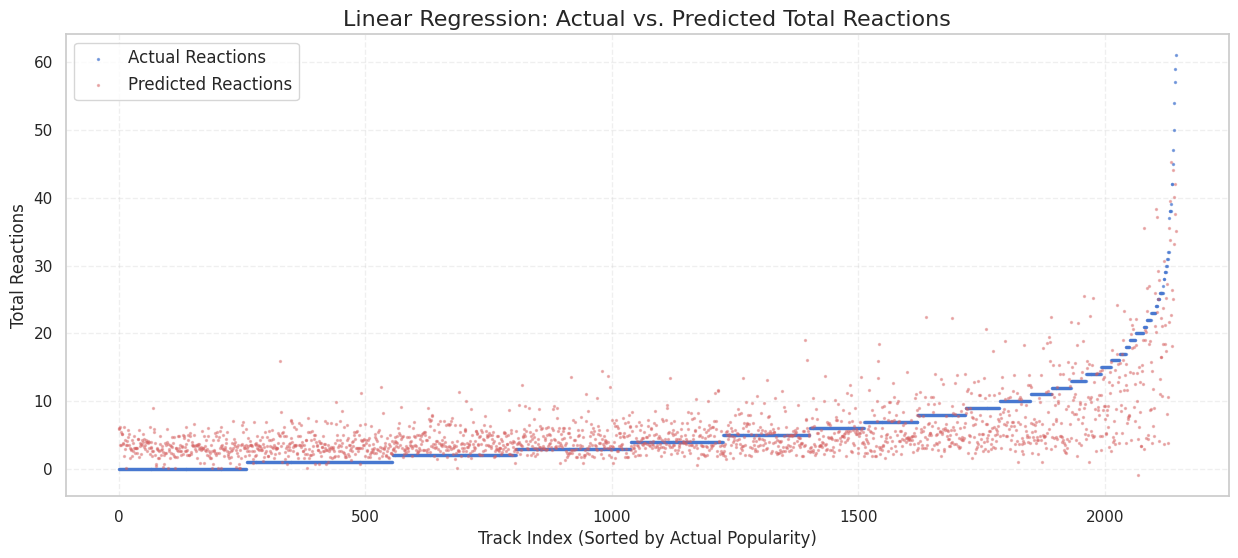

In [9]:
plot_actual_vs_predicted("Linear Regression", y_test, y_pred_lr)

**Let's check the importance of each column as a visual plot to have better understanding of the progress:**

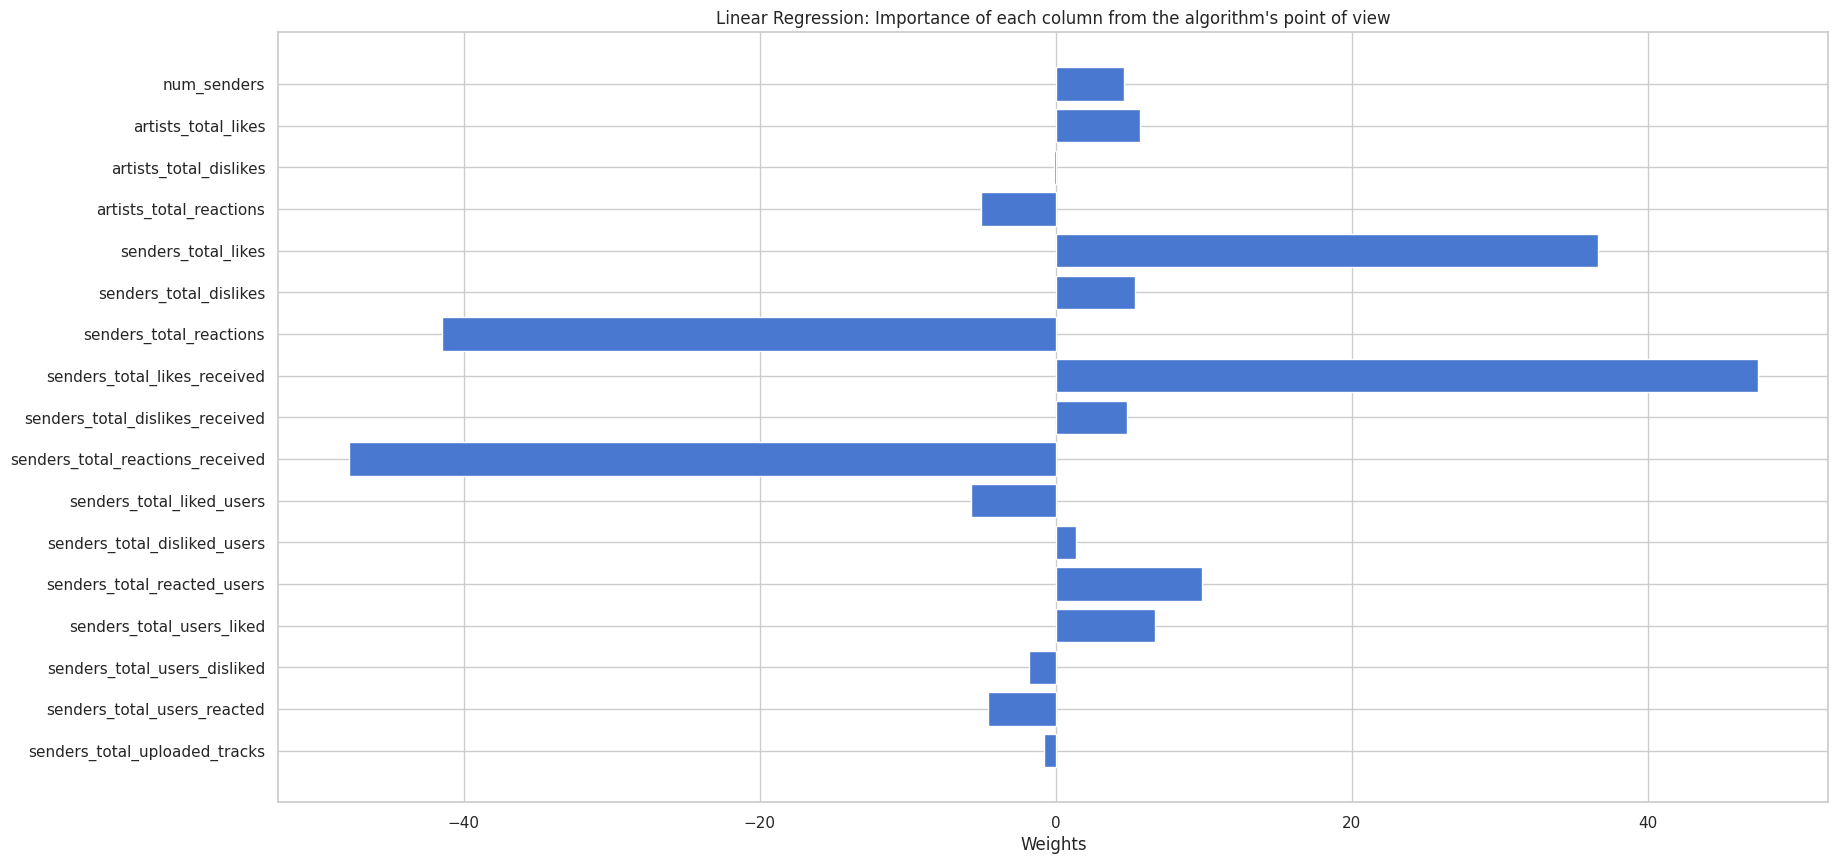

In [10]:
linear_weights = lr_model.coef_

fig, ax = plt.subplots(figsize=(20,10))
y_pos = np.arange(0,len(linear_weights),1)
labels = list(X.columns)

hbars = ax.barh(y_pos, linear_weights, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Weights')
ax.set_title("Linear Regression: Importance of each column from the algorithm's point of view")

plt.show()

#Source: Lab Session 6

### Transforming to Polynomial Regression:

In [11]:
poly = PolynomialFeatures(degree=2)
X_train_transformed_poly = poly.fit_transform(X_train)
X_test_transformed_poly = poly.transform(X_test)

print(X_train_transformed_poly.shape)

(8580, 171)


*So we have got 171 features out of 17 features, but how many of them are actually useful ❓*

Text(0, 0.5, 'Cumulative percetnage of feature scores')

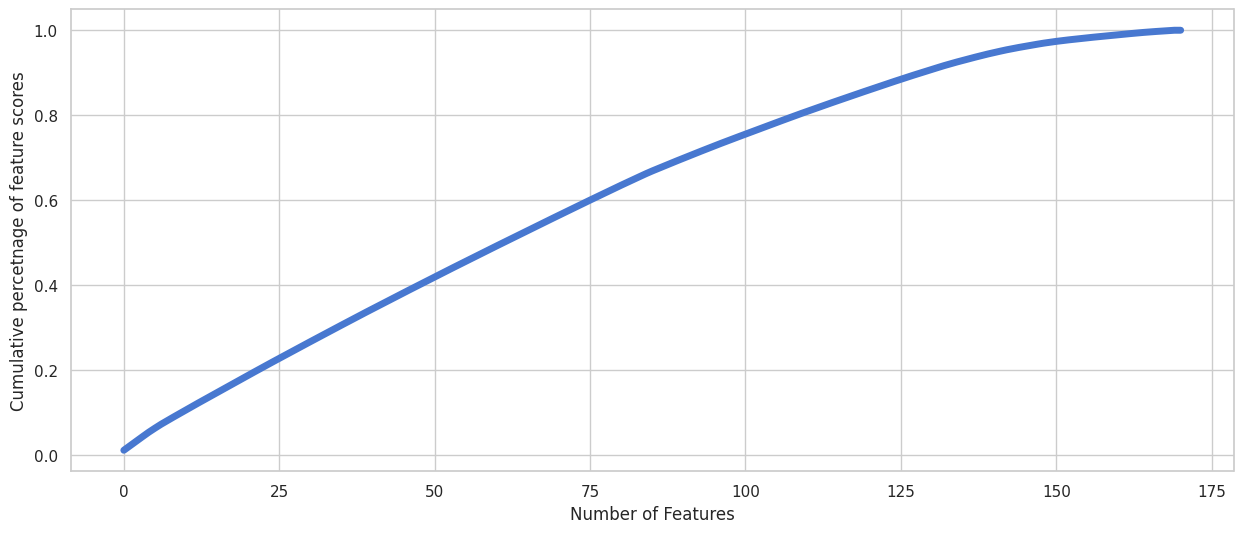

In [12]:
feature_selector = SelectKBest(score_func=mutual_info_regression, k = 'all').fit(X_train_transformed_poly,y_train)

feature_scores = feature_selector.scores_
plt.figure(figsize=(15,6))
plt.plot(np.cumsum(np.sort(np.abs(feature_scores))[::-1])/sum(np.abs(feature_scores)),lw=5)
plt.xlabel('Number of Features')
plt.ylabel('Cumulative percetnage of feature scores')

From the above plot it seems that 150 features are good to go but let's test it:

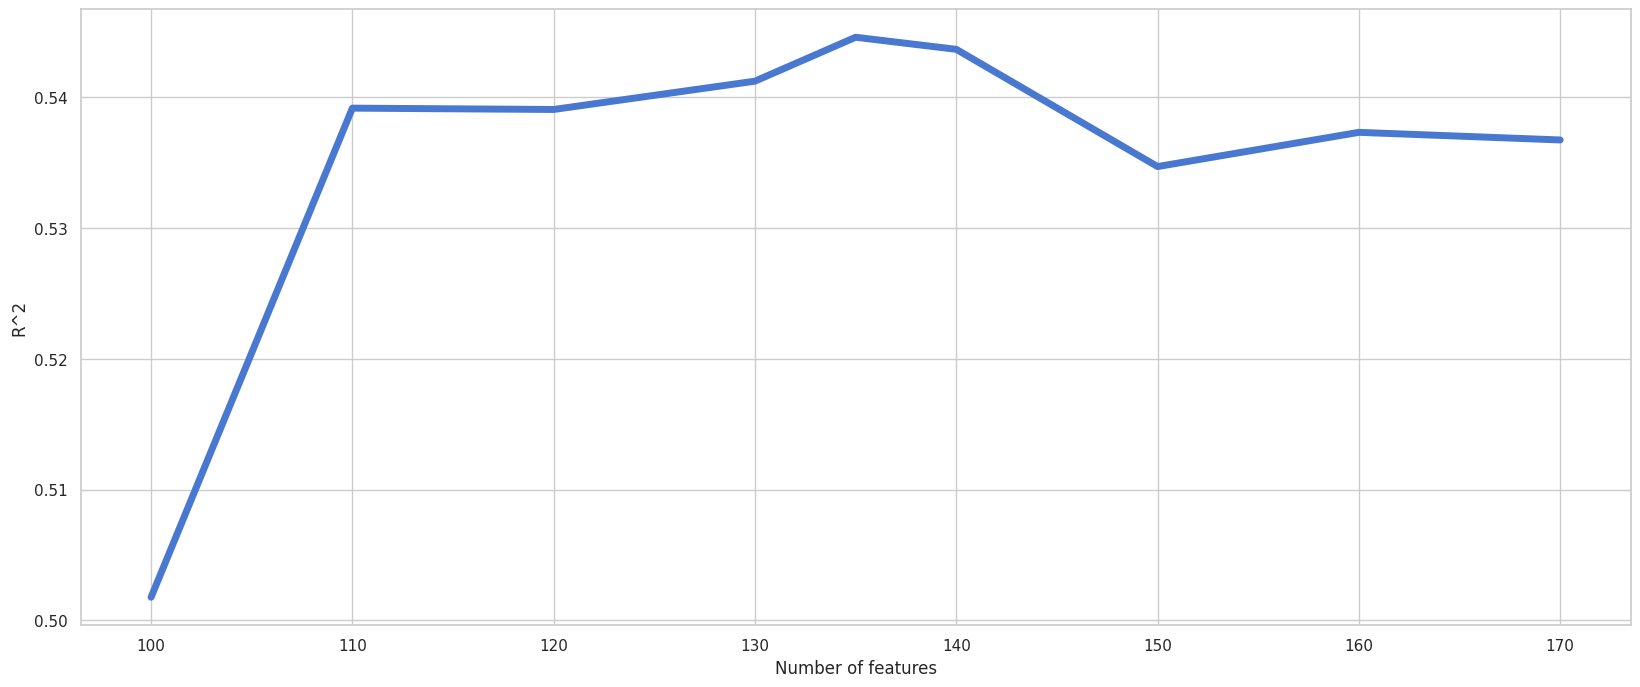

In [13]:
no_features = []
scores = []

for k in [100,110,120,130,135,140,150,160,170]:

    # Select best features
    selector = SelectKBest(mutual_info_regression, k = k)
    selector.fit(X_train_transformed_poly, y_train)
    X_train_transformed = selector.transform(X_train_transformed_poly)
    X_test_transform = selector.transform(X_test_transformed_poly)

    # Create the model
    model = LinearRegression()
    model.fit(X_train_transformed, y_train)
    no_features.append(k)
    predicted_results = cap_vector(model.predict(X_test_transform),100000,0)
    r2_test = r2_score(y_test, predicted_results)
    scores.append(r2_test)


# Plot the results
plt.figure(figsize=(20,8))
plt.plot(no_features,scores,lw=5)
plt.xlabel('Number of features')
plt.ylabel('R^2')
plt.show()

**So according to results we go with `k=140` as our optimal choice.**

In [14]:
selector = SelectKBest(mutual_info_regression, k = 140)
selector.fit(X_train_transformed_poly, y_train)
X_train_transformed = selector.transform(X_train_transformed_poly)
X_test_transform = selector.transform(X_test_transformed_poly)

# --- Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_transformed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
predicted_results = cap_vector(lr_model.predict(X_test_transform),100000,0)
evaluate_regression("Linear Regression (140 parameters)", y_test, predicted_results)

,MSE,MAE,MAPE,R2,RMSLE,MedAE
Linear Regression,19.0116,3.0971,1.80e+15,0.520247,0.7497,2.3612
Linear Regression (140 parameters),18.0828,3.0381,1.72e+15,0.543685,0.7296,2.3747


*👀 We saw that one comming, our prevoius linear regression R^2 value had a solid 0.52 value so we really didn't expect it to fire rocket, but to be honest 0.02 progress in R^2 is not that mouch of difference in our case.*

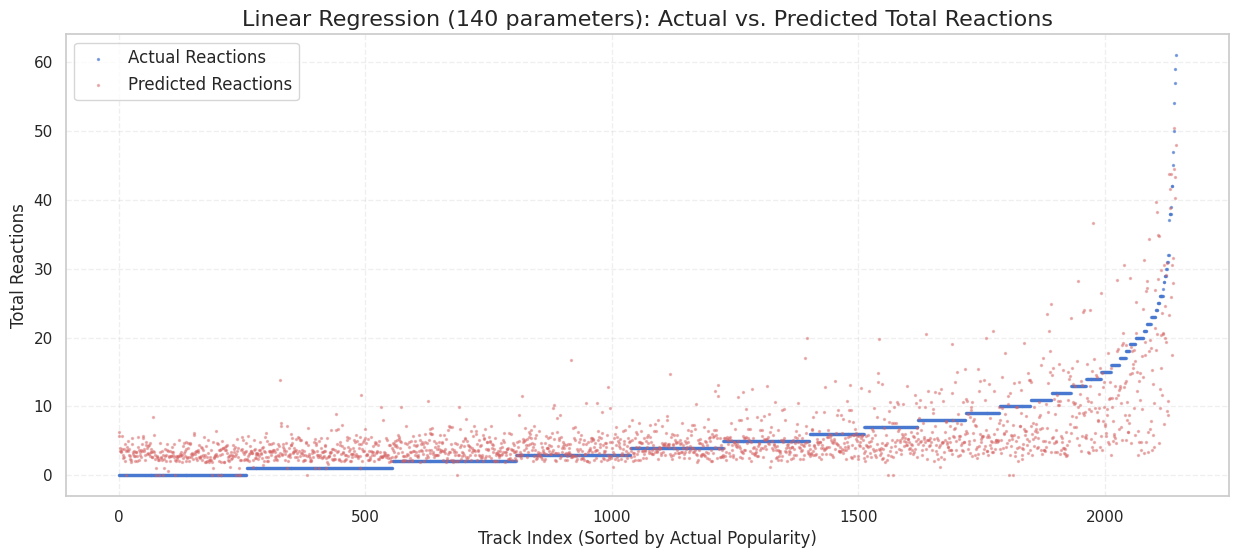

In [16]:
plot_actual_vs_predicted("Linear Regression (140 parameters)", y_test, predicted_results)

*As we can see from the plot, the model has better behavior in popular tracks and can guess much higher numbers.*

### 1.2 Ridge Regression

In [17]:
# --- Ridge Regression ---
# We can tune alpha via GridSearchCV broadly
ridge_cv = GridSearchCV(Ridge(), param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also d

In [18]:
y_pred_ridge = ridge_cv.predict(X_test_scaled)
print(f"🔸 Ridge optimal alpha: {ridge_cv.best_params_['alpha']}")
evaluate_regression("Ridge Regression", y_test, y_pred_ridge)

🔸 Ridge optimal alpha: 0.01


,MSE,MAE,MAPE,R2,RMSLE,MedAE
Linear Regression,19.0116,3.0971,1.80e+15,0.520247,0.7497,2.3612
Linear Regression (140 parameters),18.0828,3.0381,1.72e+15,0.543685,0.7296,2.3747
Ridge Regression,19.0117,3.0973,1.80e+15,0.520245,0.7497,2.3651


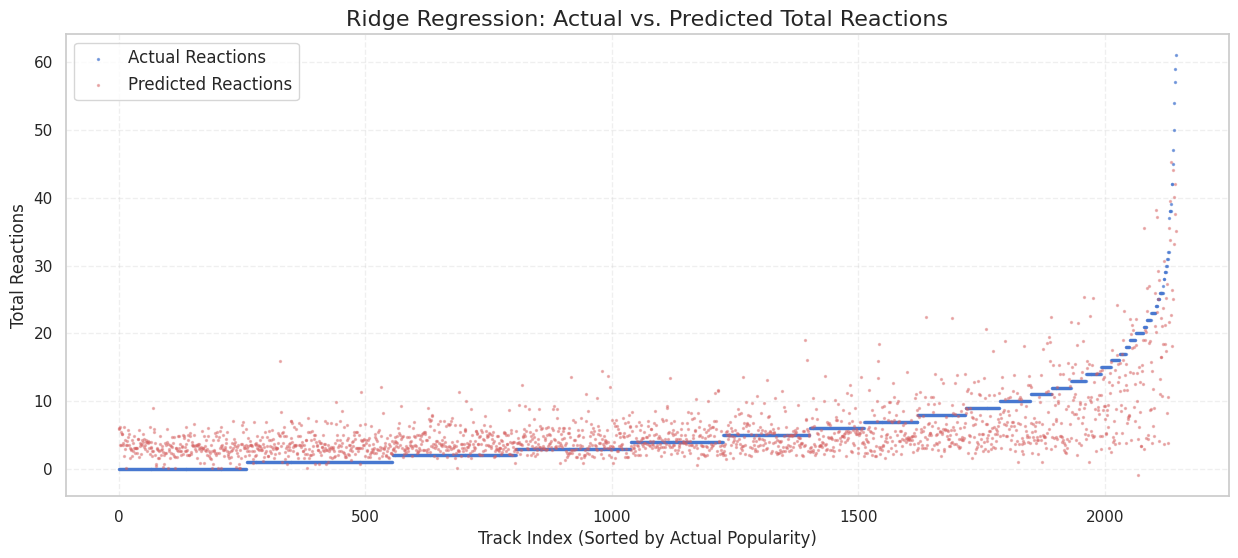

In [19]:
plot_actual_vs_predicted("Ridge Regression", y_test, y_pred_ridge)

*The behavior of the model is much more like normal linear regression than to increased parameter one.*

#### Effect of regularization coefficient
**Let's check the behavior of the model according to alpha:**

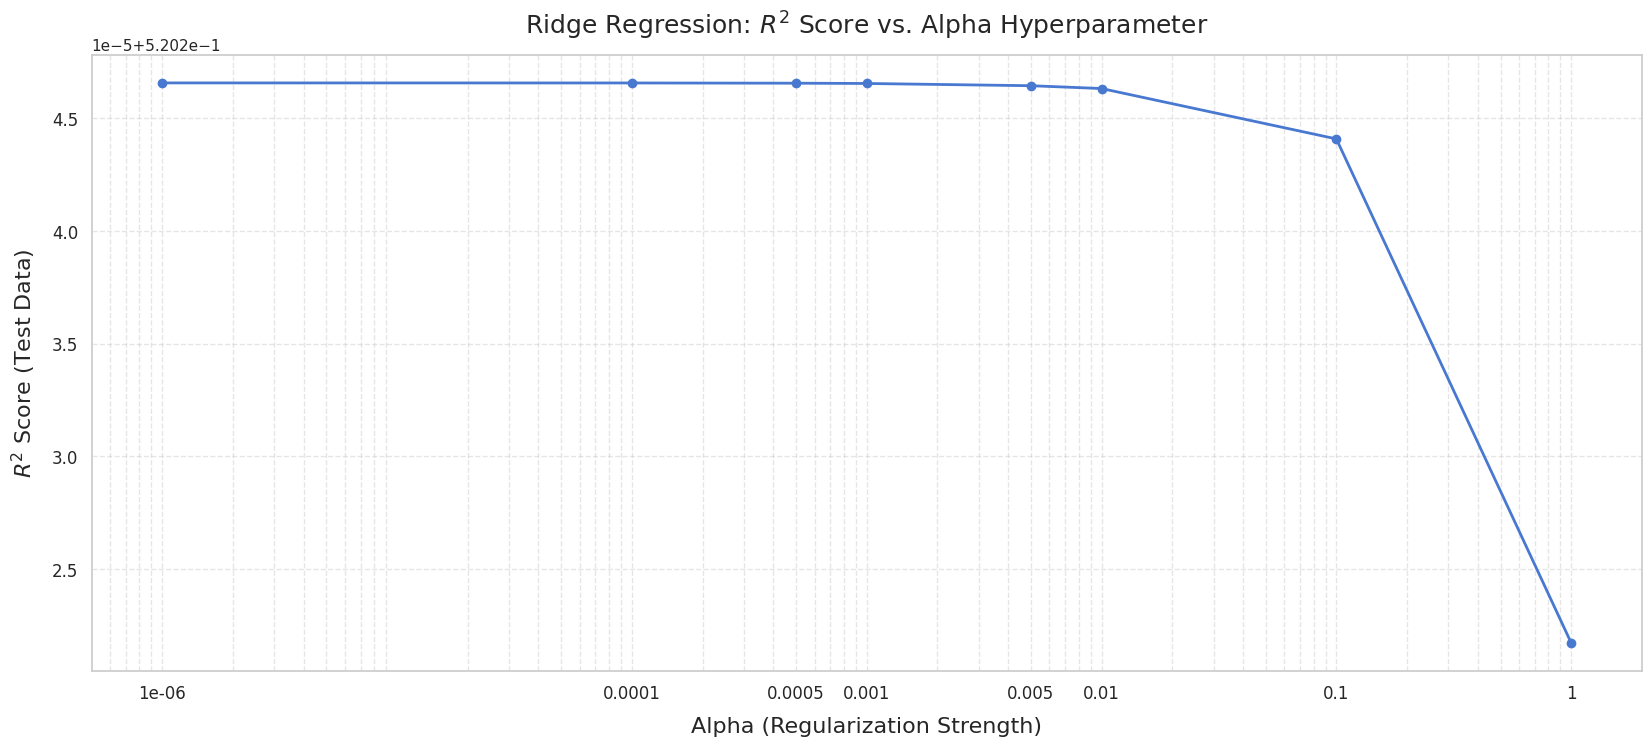

In [20]:
alpha_list = [0.000001,.0001,.0005,.001,.005,0.01,.1,1]
scores = []
for alpha in alpha_list:
  model = Ridge(alpha=alpha)
  model.fit(X_train, y_train)
  predicted_value = model.predict(X_test)
  r2_test = r2_score(y_test, predicted_value)
  scores.append(r2_test)

plt.figure(figsize=(20, 8))
plt.plot(alpha_list, scores, marker='o', linewidth=2, color='b')

# 1. Change X-axis to a logarithmic scale (fixes the squishing issue)
plt.xscale('log')

# 2. Force the X-axis ticks to match your exact alpha values
plt.xticks(alpha_list, labels=[str(a) for a in alpha_list], fontsize=12)
plt.yticks(fontsize=12)

plt.xlabel('Alpha (Regularization Strength)', fontsize=16, labelpad=10)
plt.ylabel('$R^2$ Score (Test Data)', fontsize=16, labelpad=10)
plt.title('Ridge Regression: $R^2$ Score vs. Alpha Hyperparameter', fontsize=18, pad=15)
plt.grid(True, which="both", linestyle='--', alpha=0.5)

plt.show()

**As we can see we can select `0.01` or `0.1` as our optimal alpha**.

#### Ridge Regression with polynomial parameters:

Let's also test the Ridge Regression with our previous `k=140` parameters and notice the result

In [21]:
selector = SelectKBest(mutual_info_regression, k = 140)
selector.fit(X_train_transformed_poly, y_train)
X_train_transformed = selector.transform(X_train_transformed_poly)
X_test_transform = selector.transform(X_test_transformed_poly)

# --- Ridge Regression -with k=140 ---
ridge_cv = GridSearchCV(Ridge(), param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}, cv=5)
ridge_cv.fit(X_train_transformed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also d

In [22]:
ridge_predicted_results = cap_vector(ridge_cv.predict(X_test_transform),100000,0)
print(f"🔸 Ridge optimal alpha: {ridge_cv.best_params_['alpha']}")
evaluate_regression("Ridge Regression (140 parameters)", y_test, ridge_predicted_results)

🔸 Ridge optimal alpha: 0.01


,MSE,MAE,MAPE,R2,RMSLE,MedAE
Linear Regression,19.0116,3.0971,1.80e+15,0.520247,0.7497,2.3612
Linear Regression (140 parameters),18.0828,3.0381,1.72e+15,0.543685,0.7296,2.3747
Ridge Regression,19.0117,3.0973,1.80e+15,0.520245,0.7497,2.3651
Ridge Regression (140 parameters),18.1112,3.0389,1.72e+15,0.542967,0.7301,2.3560


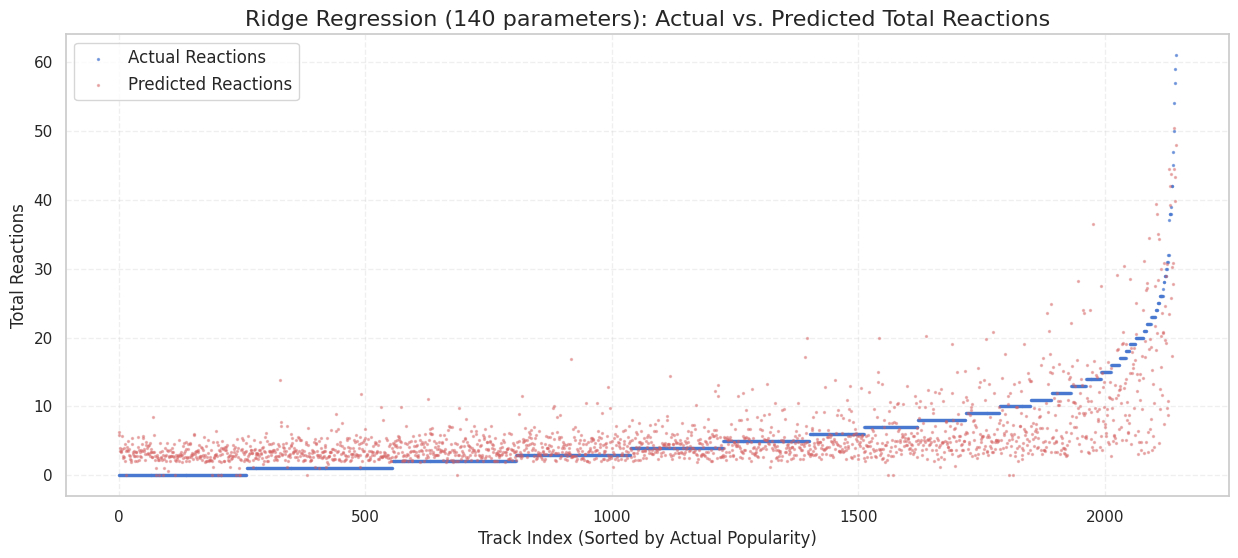

In [23]:
plot_actual_vs_predicted("Ridge Regression (140 parameters)", y_test, ridge_predicted_results)

*We got better results in polynomial version like in Linear Regression but the results still lack!*

### 1.3 LASSO Regression


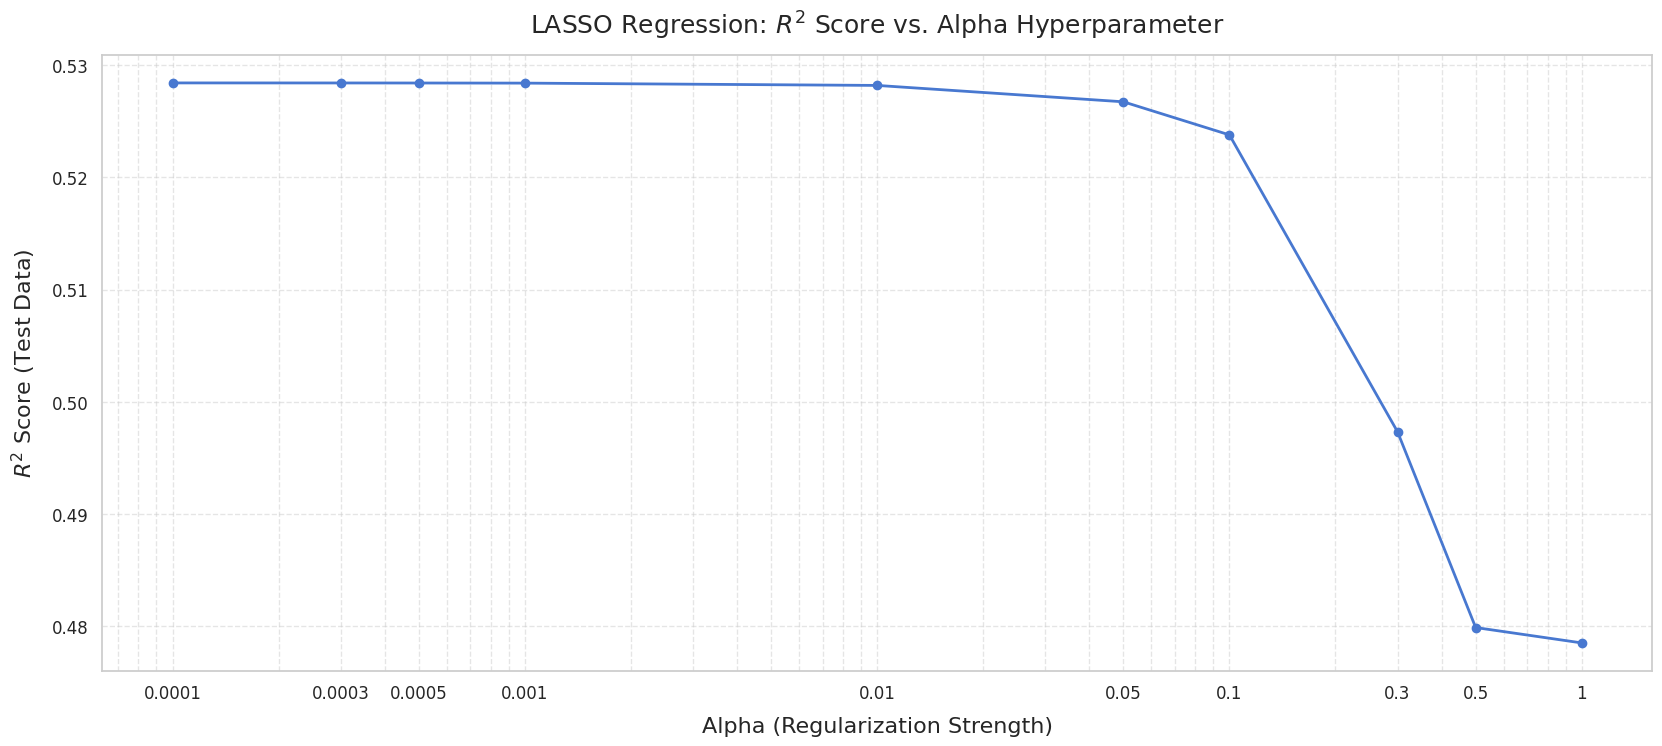

In [24]:

no_features = []
scores = []
# Select best features
selector = SelectKBest(mutual_info_regression, k = 140)
selector.fit(X_train_transformed_poly, y_train)
X_train_transformed = selector.transform(X_train_transformed_poly)
X_test_transform = selector.transform(X_test_transformed_poly)

alpha_list = [.0001,0.0003,0.0005,0.001,0.01,0.05,0.1,0.3,0.5,1]
scores = []
for alpha in alpha_list:
    model = Lasso(alpha=alpha)
    model.fit(X_train_transformed, y_train)
    no_features.append(k)
    predicted_prices_test = model.predict(X_test_transform)
    r2_test = r2_score(y_test, predicted_prices_test)
    scores.append(r2_test)

# Plot the results
plt.figure(figsize=(20, 8))
plt.plot(alpha_list, scores, marker='o', linewidth=2, color='b')

# 1. Change X-axis to a logarithmic scale (fixes the squishing issue)
plt.xscale('log')

# 2. Force the X-axis ticks to match your exact alpha values
plt.xticks(alpha_list, labels=[str(a) for a in alpha_list], fontsize=12)
plt.yticks(fontsize=12)

plt.xlabel('Alpha (Regularization Strength)', fontsize=16, labelpad=10)
plt.ylabel('$R^2$ Score (Test Data)', fontsize=16, labelpad=10)
plt.title('LASSO Regression: $R^2$ Score vs. Alpha Hyperparameter', fontsize=18, pad=15)
plt.grid(True, which="both", linestyle='--', alpha=0.5)

plt.show()

*So we again go with the `alpha=0.01` as our hyperparameter choice.*

In [25]:
# --- LASSO Regression ---
lasso_cv = GridSearchCV(Lasso(max_iter=5000), param_grid={'alpha': [0.01, 0.1, 1.0, 10.0]}, cv=5)
lasso_cv.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso(max_iter=5000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter index

In [26]:
y_pred_lasso = lasso_cv.predict(X_test_scaled)
print(f"🔸 LASSO optimal alpha: {lasso_cv.best_params_['alpha']}")
evaluate_regression("LASSO Regression", y_test, y_pred_lasso)

🔸 LASSO optimal alpha: 0.01


,MSE,MAE,MAPE,R2,RMSLE,MedAE
Linear Regression,19.0116,3.0971,1.80e+15,0.520247,0.7497,2.3612
Linear Regression (140 parameters),18.0828,3.0381,1.72e+15,0.543685,0.7296,2.3747
Ridge Regression,19.0117,3.0973,1.80e+15,0.520245,0.7497,2.3651
Ridge Regression (140 parameters),18.1112,3.0389,1.72e+15,0.542967,0.7301,2.3560
LASSO Regression,19.8151,3.1920,1.96e+15,0.499971,0.7740,2.4587


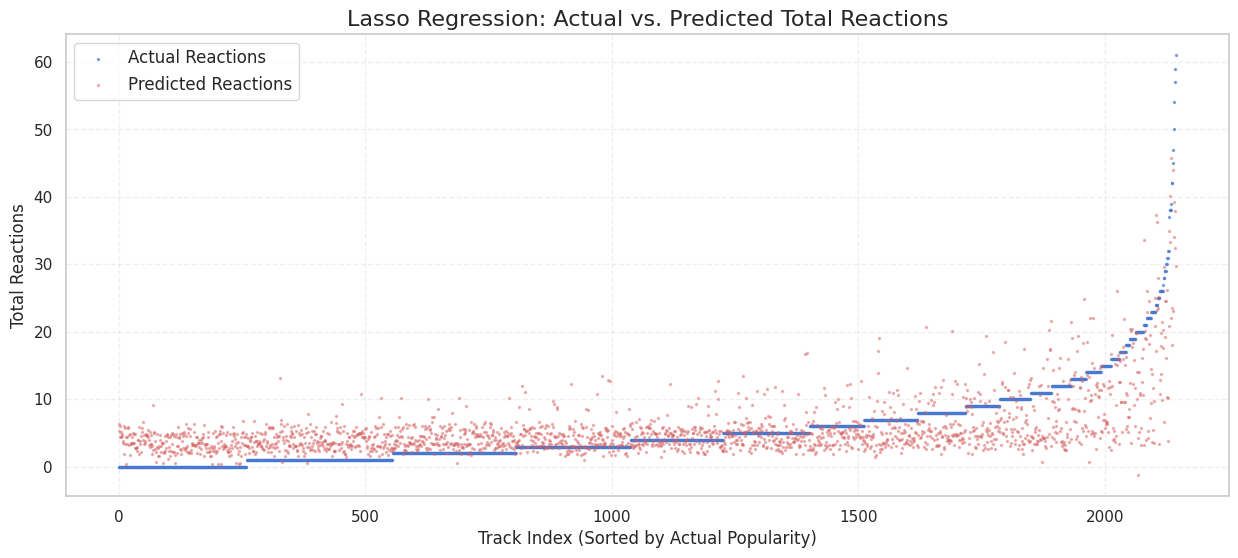

In [27]:
plot_actual_vs_predicted("Lasso Regression", y_test, y_pred_lasso)

#### LASSO Regression polynomial parameters

In [28]:
selector = SelectKBest(mutual_info_regression, k = 140)
selector.fit(X_train_transformed_poly, y_train)
X_train_transformed = selector.transform(X_train_transformed_poly)
X_test_transform = selector.transform(X_test_transformed_poly)

# --- LASSO Regression ---
lasso_cv = GridSearchCV(Lasso(), param_grid={'alpha': [0.01, 0.1, 1.0, 10.0]}, cv=5)
lasso_cv.fit(X_train_transformed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also d

In [29]:
lasso_predicted_results = cap_vector(lasso_cv.predict(X_test_transform),100000,0)
print(f"🔸 LASSO optimal alpha: {lasso_cv.best_params_['alpha']}")
evaluate_regression("LASSO Regression (140 parameters)", y_test, lasso_predicted_results)

🔸 LASSO optimal alpha: 0.01


,MSE,MAE,MAPE,R2,RMSLE,MedAE
Linear Regression,19.0116,3.0971,1.80e+15,0.520247,0.7497,2.3612
Linear Regression (140 parameters),18.0828,3.0381,1.72e+15,0.543685,0.7296,2.3747
Ridge Regression,19.0117,3.0973,1.80e+15,0.520245,0.7497,2.3651
Ridge Regression (140 parameters),18.1112,3.0389,1.72e+15,0.542967,0.7301,2.3560
LASSO Regression,19.8151,3.1920,1.96e+15,0.499971,0.7740,2.4587
LASSO Regression (140 parameters),18.6116,3.0786,1.77e+15,0.530341,0.7392,2.3282


#### Sparsity in the Weights and Feature Selection in LASSO regression

> Here we are going to set a larger alphs (in this case `alpha = 0.1`) to demonstrate removal of parameters by the LASSO Regression model and  then would compare the model weights with the first Linear Regression model weights

In [30]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)

lasso_weights = lasso_model.coef_
print('Non-zero weights in Lasso regression %d' %(sum(lasso_weights!=0)))

Non-zero weights in Lasso regression 7


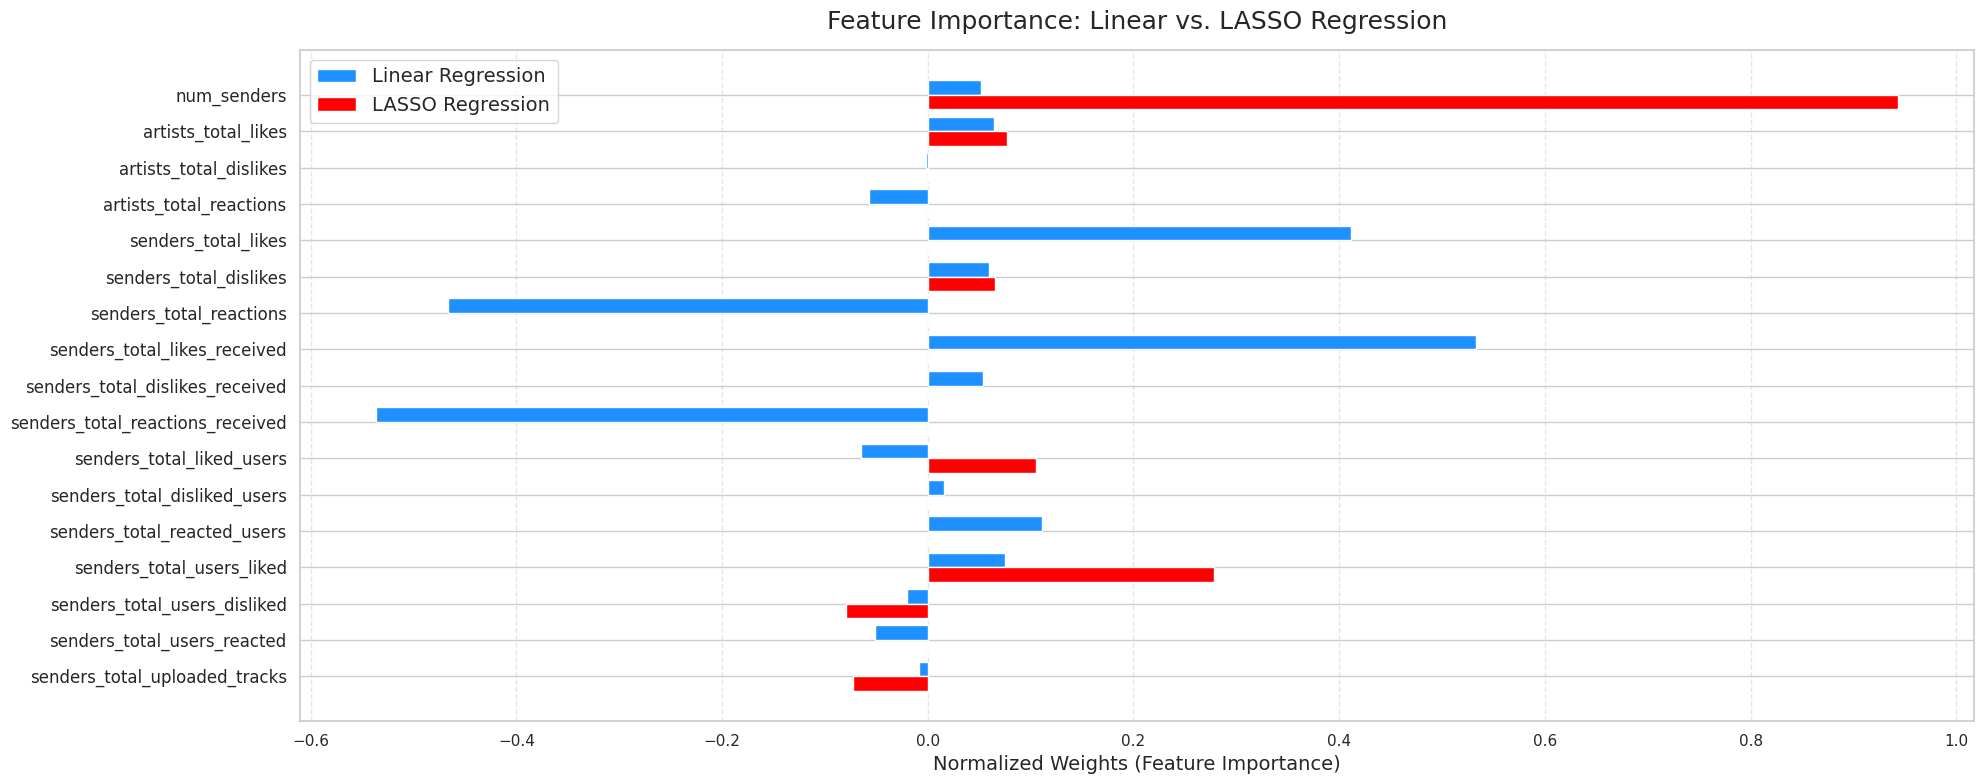

In [31]:
fig, ax = plt.subplots(figsize=(20, 8))
y_pos = np.arange(0, len(lasso_weights), 1)

# Plot Linear weights in blue
hbars_linear = ax.barh(y_pos, linear_weights/np.linalg.norm(linear_weights), 
                       align='center', color='dodgerblue', height=0.4, label='Linear Regression')

# Plot Lasso weights in red (offset by 0.4 to sit perfectly side-by-side)
hbars_lasso = ax.barh(y_pos+0.4, lasso_weights/np.linalg.norm(lasso_weights), 
                      align='center', color='red', height=0.4, label='LASSO Regression')

# Adjust tick placement to sit perfectly between the two bars
ax.set_yticks(y_pos + 0.2)
ax.set_yticklabels(labels, fontsize=12)
ax.invert_yaxis()  # Labels read top-to-bottom

ax.set_xlabel('Normalized Weights (Feature Importance)', fontsize=14)
ax.set_title("Feature Importance: Linear vs. LASSO Regression", fontsize=18, pad=15)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

# Add the legend to distinguish the colors
ax.legend(fontsize=14, loc='best')

plt.tight_layout()
plt.show()

**As we can see from the plot result, only `7 parameters are non-zero` inside the LASSO Regression model, and also the weight selection is a lot different than the one in Linear Regression**

### 1.4 Kernel Regression


In [ ]:
# --- Kernel Regression (sigmoid)---
if 1: # You'd better keep your pc tight, why? it's going to fly, because it's fan is going to blow like a jet engine :)
    kr_sig_model = KernelRidge(kernel='sigmoid')
    kr_sig_model.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`. If an array is passed, penalties areassumed to be specific to the targets. Hence they must correspond innumber. See :ref:`ridge_regression` for formula.",1
,"kernel kernel: str or callable, default=""linear""Kernel mapping used internally. This parameter is directly passed to:class:`~sklearn.metrics.pairwise.pairwise_kernels`.If `kernel` is a string, it must be one of the metricsin `pairwise.PAIRWISE_KERNEL_FUNCTIONS` or ""precomputed"".If `kernel` is ""precomputed"", X is assumed to be a kernel matrix.Alternatively, if `kernel` is a callable function, it is called oneach pair of instances (rows) and the resulting value recorded. Thecallable should take two rows from X as input and return thecorresponding kernel value as a single number. This means thatcallables from :mod:`sklearn.metrics.pairwise` are not allowed, asthey operate on matrices, not single samples. Use the stringidentifying the kernel instead.",'sigmoid'
,"gamma gamma: float, default=NoneGamma parameter for the RBF, laplacian, polynomial, exponential chi2and sigmoid kernels. Interpretation of the default value is left tothe kernel; see the documentation for sklearn.metrics.pairwise.Ignored by other kernels.",None
,"degree degree: float, default=3Degree of the polynomial kernel. Ignored by other kernels.",3
,"coef0 coef0: float, default=1Zero coefficient for polynomial and sigmoid kernels.Ignored by other kernels.",1
,"kernel_params kernel_params: dict, default=NoneAdditional parameters (keyword arguments) for kernel function passedas callable object.",None


In [ ]:
y_pred_kr = kr_sig_model.predict(X_test_scaled)
evaluate_regression("Kernel Regression (sigmoid)", y_test, y_pred_kr)

,MSE,MAE,MAPE,R2,RMSLE,MedAE
Linear Regression,19.0116,3.0971,1.80e+15,0.520247,0.7497,2.3612
Linear Regression (140 parameters),18.0828,3.0381,1.72e+15,0.543685,0.7296,2.3747
Ridge Regression,19.0117,3.0973,1.80e+15,0.520245,0.7497,2.3651
Ridge Regression (140 parameters),18.1112,3.0389,1.72e+15,0.542967,0.7301,2.3560
LASSO Regression,19.8151,3.1920,1.96e+15,0.499971,0.7740,2.4587
LASSO Regression (140 parameters),18.6116,3.0786,1.77e+15,0.530341,0.7392,2.3282
Kernel Regression (RBF),131033872.6897,5608.8665,2.42e+18,-3306607.784061,4.8050,3241.2011
Decision Tree Regression,18.3890,2.9327,1.51e+15,0.535958,0.6902,2.3994
Kernel Regression (sigmoid),131033872.6897,5608.8665,2.42e+18,-3306607.784061,4.8050,3241.2011


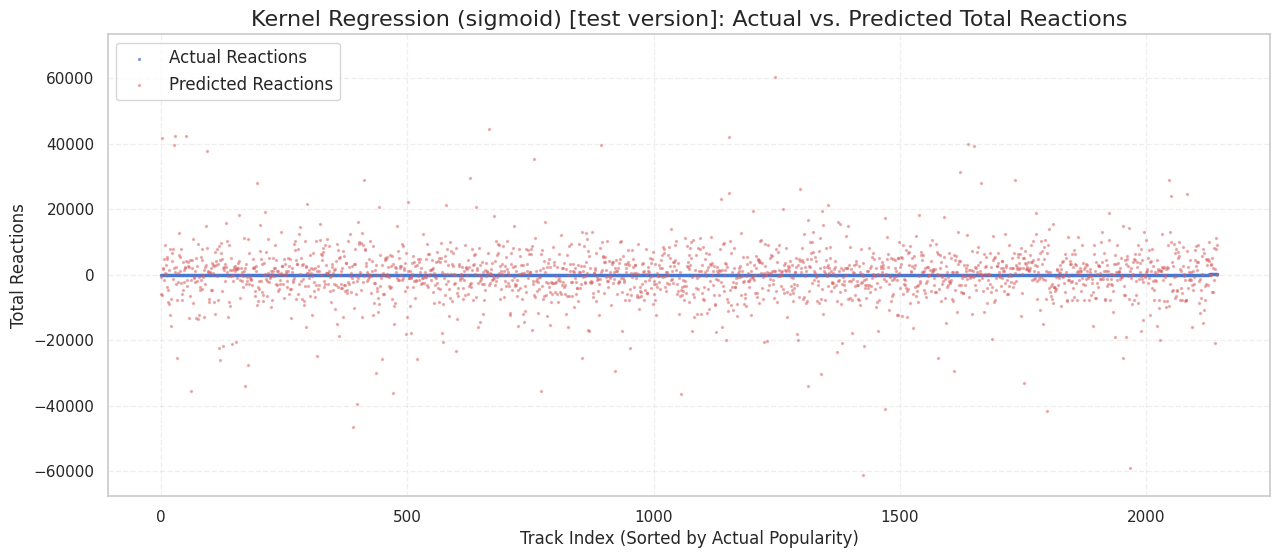

In [39]:
plot_actual_vs_predicted("Kernel Regression (sigmoid) [test version]", y_test, y_pred_kr)

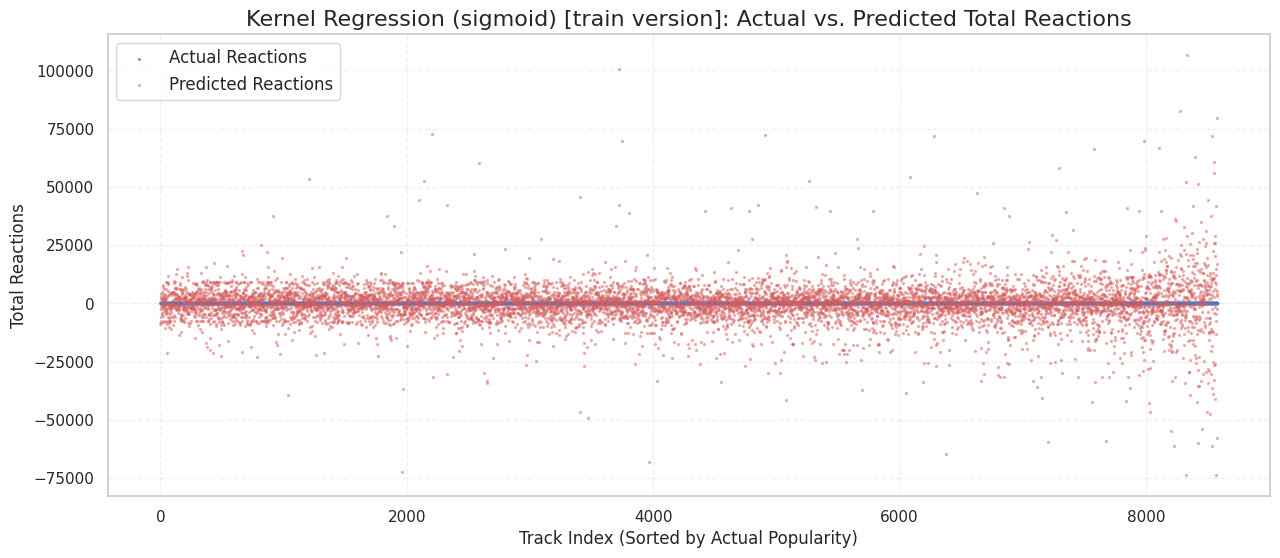

In [ ]:
y_pred_kr_train = kr_sig_model.predict(X_train_scaled)
plot_actual_vs_predicted("Kernel Regression (sigmoid) [train version]", y_train, y_pred_kr_train)

***Absolute Mess!!***

> I guess having a random generate to generate random number between 0 to 60 would have work much more better!

In [ ]:
# --- Kernel Ridge Regression (RBF)---
# RBF matches features based on their localized gaussian distance.
kr_rbf_model = KernelRidge(kernel='rbf', alpha=1.0, gamma=0.1)
kr_rbf_model.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`. If an array is passed, penalties areassumed to be specific to the targets. Hence they must correspond innumber. See :ref:`ridge_regression` for formula.",1.0
,"kernel kernel: str or callable, default=""linear""Kernel mapping used internally. This parameter is directly passed to:class:`~sklearn.metrics.pairwise.pairwise_kernels`.If `kernel` is a string, it must be one of the metricsin `pairwise.PAIRWISE_KERNEL_FUNCTIONS` or ""precomputed"".If `kernel` is ""precomputed"", X is assumed to be a kernel matrix.Alternatively, if `kernel` is a callable function, it is called oneach pair of instances (rows) and the resulting value recorded. Thecallable should take two rows from X as input and return thecorresponding kernel value as a single number. This means thatcallables from :mod:`sklearn.metrics.pairwise` are not allowed, asthey operate on matrices, not single samples. Use the stringidentifying the kernel instead.",'rbf'
,"gamma gamma: float, default=NoneGamma parameter for the RBF, laplacian, polynomial, exponential chi2and sigmoid kernels. Interpretation of the default value is left tothe kernel; see the documentation for sklearn.metrics.pairwise.Ignored by other kernels.",0.1
,"degree degree: float, default=3Degree of the polynomial kernel. Ignored by other kernels.",3
,"coef0 coef0: float, default=1Zero coefficient for polynomial and sigmoid kernels.Ignored by other kernels.",1
,"kernel_params kernel_params: dict, default=NoneAdditional parameters (keyword arguments) for kernel function passedas callable object.",None


In [43]:
y_pred_kr = kr_rbf_model.predict(X_test_scaled)
evaluate_regression("Kernel Regression (rbf)", y_test, y_pred_kr)

,MSE,MAE,MAPE,R2,RMSLE,MedAE
Linear Regression,19.0116,3.0971,1.80e+15,0.520247,0.7497,2.3612
Linear Regression (140 parameters),18.0828,3.0381,1.72e+15,0.543685,0.7296,2.3747
Ridge Regression,19.0117,3.0973,1.80e+15,0.520245,0.7497,2.3651
Ridge Regression (140 parameters),18.1112,3.0389,1.72e+15,0.542967,0.7301,2.3560
LASSO Regression,19.8151,3.1920,1.96e+15,0.499971,0.7740,2.4587
LASSO Regression (140 parameters),18.6116,3.0786,1.77e+15,0.530341,0.7392,2.3282
Kernel Regression (RBF),131033872.6897,5608.8665,2.42e+18,-3306607.784061,4.8050,3241.2011
Decision Tree Regression,18.3890,2.9327,1.51e+15,0.535958,0.6902,2.3994
Kernel Regression (sigmoid),76691868.9006,5366.1720,2.51e+18,-1045922.295231,4.9335,3462.4854
Kernel Regression (rbf),20.7579,3.0593,1.69e+15,0.476178,0.7224,2.2803


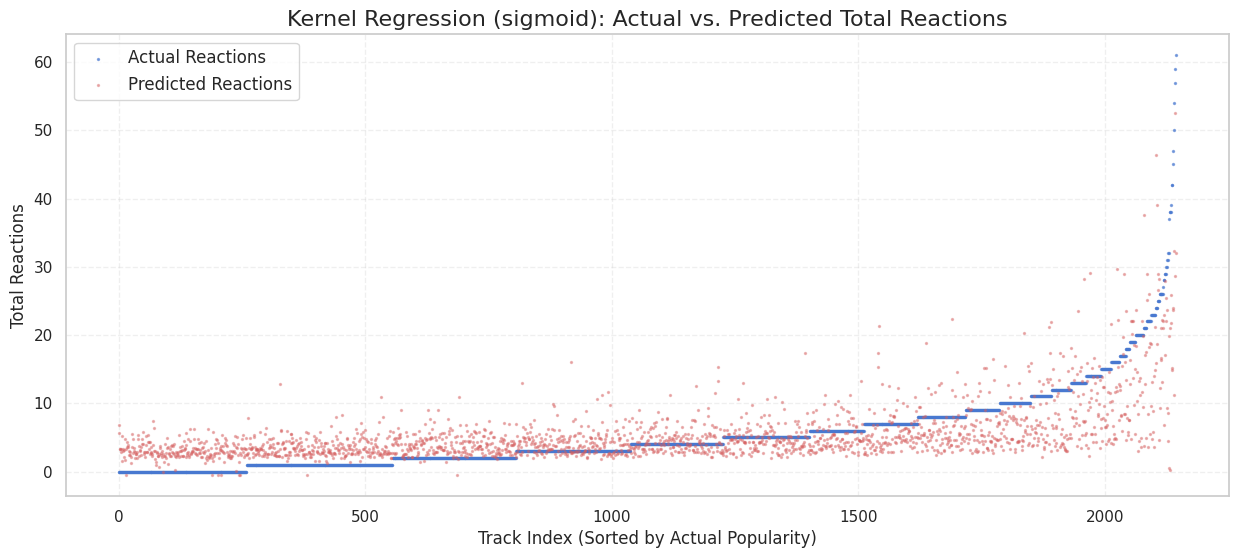

In [44]:
plot_actual_vs_predicted("Kernel Regression (sigmoid)", y_test, y_pred_kr)

**Much better result than the sigmoid version but still the worst result from the R^2 prespective**

#### The Exploding Kernel Regression Collapse

Looking at the summary table, there is a massive anomaly: **Kernel Regression (RBF with default settings/unoptimized space)** and **Kernel Regression (sigmoid)** completely collapsed. 

* **Kernel Regression (sigmoid):** $R^2 = -1,045,922.29$ | $MAE = 5,366.17$
* **Kernel Regression (rbf - Row 9):** $R^2 = 0.4762$ | $MAE = 3.05$

An $R^2$ that deeply negative means the model performed significantly worse than a horizontal line drawn at the dataset's average. 

##### Why the Sigmoid Kernel Blew Up?
The Sigmoid Kernel calculates similarity using a hyperbolic tangent activation:
$$K(X_i, X_j) = \tanh(\gamma \langle X_i, X_j \rangle + c_0)$$

Because we used `KernelRidge(kernel='sigmoid')` with default hyper-parameters:
* **The Default Hyperparameter Trap:** By default, `alpha=1` (regularization) and `gamma=None` (which defaults to $1 / n_{\text{features}}$). 
* **The Saturation Phenomenon:** When features are highly dense, or if the variance shifts, the dot product inside the $\tanh$ function gets large. The sigmoid function completely saturates at its extreme limits ($+1$ or $-1$). 
* **The Mathematical Result:** The kernel matrix becomes highly singular and unstable (ill-conditioned). When Ridge attempts to invert this matrix to solve for dual coefficients, the math collapses. The model outputs wildly extreme, erratic coefficients, resulting in individual predictions missing by thousands of reactions.


### 1.5 Desision Tree Regression (Optional)
We chose **Decision Tree Regression** as our optional model as it solves nonlinearity by splitting feature spaces instead!

In [45]:
# --- Decision Tree Regression (Bonus) ---
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [46]:
y_pred_dt = dt_model.predict(X_test_scaled)
evaluate_regression("Decision Tree Regression", y_test, y_pred_dt)

,MSE,MAE,MAPE,R2,RMSLE,MedAE
Linear Regression,19.0116,3.0971,1.80e+15,0.520247,0.7497,2.3612
Linear Regression (140 parameters),18.0828,3.0381,1.72e+15,0.543685,0.7296,2.3747
Ridge Regression,19.0117,3.0973,1.80e+15,0.520245,0.7497,2.3651
Ridge Regression (140 parameters),18.1112,3.0389,1.72e+15,0.542967,0.7301,2.3560
LASSO Regression,19.8151,3.1920,1.96e+15,0.499971,0.7740,2.4587
LASSO Regression (140 parameters),18.6116,3.0786,1.77e+15,0.530341,0.7392,2.3282
Kernel Regression (RBF),131033872.6897,5608.8665,2.42e+18,-3306607.784061,4.8050,3241.2011
Decision Tree Regression,18.3890,2.9327,1.51e+15,0.535958,0.6902,2.3994
Kernel Regression (sigmoid),76691868.9006,5366.1720,2.51e+18,-1045922.295231,4.9335,3462.4854
Kernel Regression (rbf),20.7579,3.0593,1.69e+15,0.476178,0.7224,2.2803


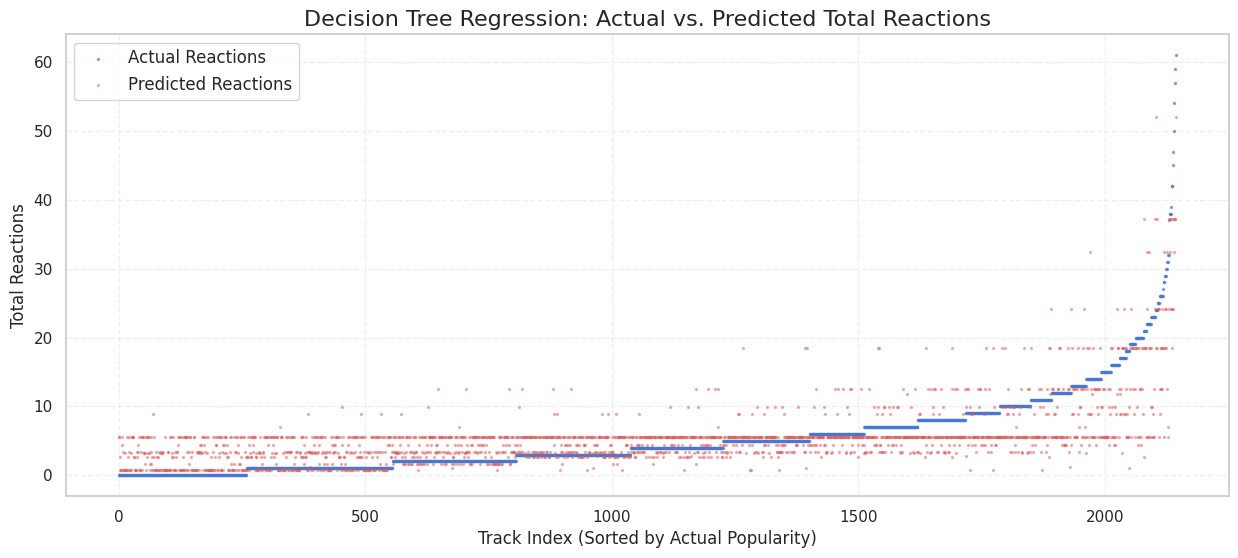

In [47]:
plot_actual_vs_predicted("Decision Tree Regression", y_test, y_pred_dt)

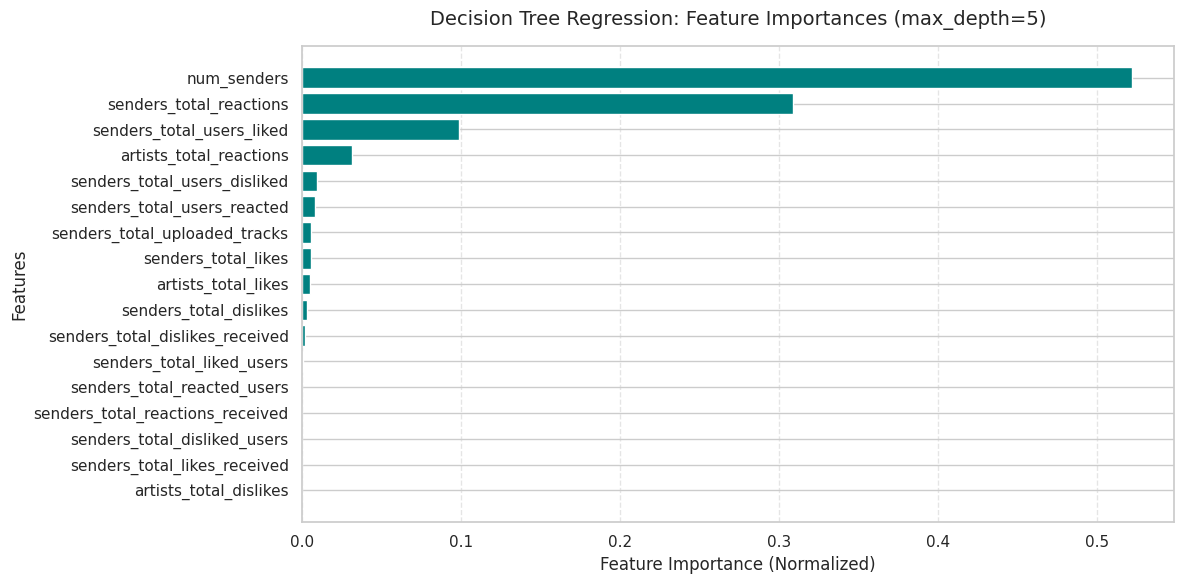

In [49]:
# 1. Extract feature importances from your trained model
importances = dt_model.feature_importances_

# 2. Match them with your feature column names (assuming X_train is a DataFrame)
feature_names = X.columns

# 3. Create a clean DataFrame and sort it from highest to lowest importance
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True) # Ascending for horizontal bar plot

# 4. Plot the feature importances
plt.figure(figsize=(12, 6))
plt.barh(df_importance['Feature'], df_importance['Importance'], color='teal')

plt.xlabel('Feature Importance (Normalized)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Decision Tree Regression: Feature Importances (max_depth=5)', fontsize=14, pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [50]:
selector = SelectKBest(mutual_info_regression, k = 140)
selector.fit(X_train_transformed_poly, y_train)
X_train_transformed = selector.transform(X_train_transformed_poly)
X_test_transform = selector.transform(X_test_transformed_poly)

# --- Decision Tree Regression (Bonus) k=140 ---
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train_transformed, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [51]:
y_pred_dt = cap_vector(dt_model.predict(X_test_transform),100000,0)
evaluate_regression("Decision Tree Regression (140 parameters)", y_test, predicted_results)

,MSE,MAE,MAPE,R2,RMSLE,MedAE
Linear Regression,19.0116,3.0971,1.80e+15,0.520247,0.7497,2.3612
Linear Regression (140 parameters),18.0828,3.0381,1.72e+15,0.543685,0.7296,2.3747
Ridge Regression,19.0117,3.0973,1.80e+15,0.520245,0.7497,2.3651
Ridge Regression (140 parameters),18.1112,3.0389,1.72e+15,0.542967,0.7301,2.3560
LASSO Regression,19.8151,3.1920,1.96e+15,0.499971,0.7740,2.4587
LASSO Regression (140 parameters),18.6116,3.0786,1.77e+15,0.530341,0.7392,2.3282
Kernel Regression (RBF),131033872.6897,5608.8665,2.42e+18,-3306607.784061,4.8050,3241.2011
Decision Tree Regression,18.3890,2.9327,1.51e+15,0.535958,0.6902,2.3994
Kernel Regression (sigmoid),76691868.9006,5366.1720,2.51e+18,-1045922.295231,4.9335,3462.4854
Kernel Regression (rbf),20.7579,3.0593,1.69e+15,0.476178,0.7224,2.2803


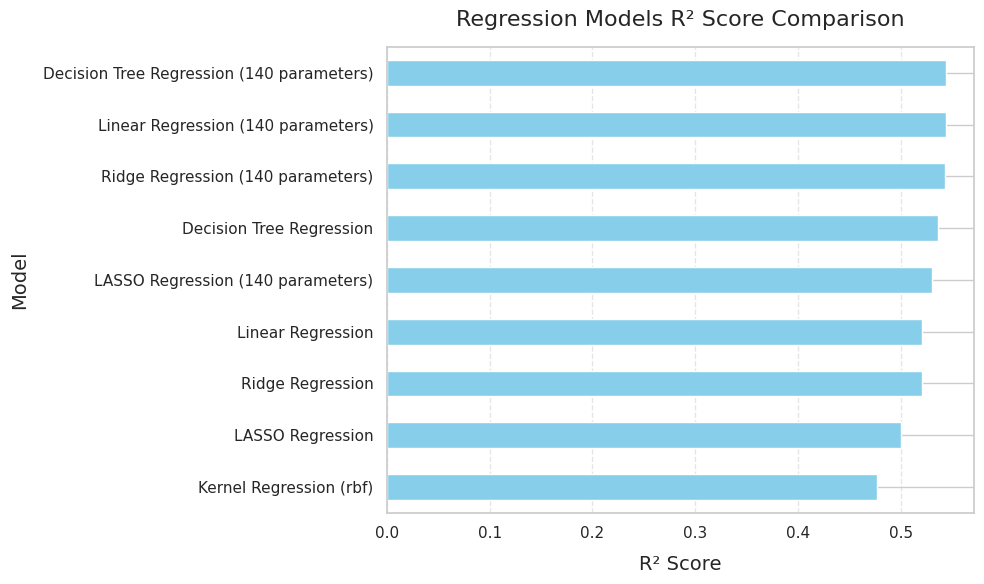

In [56]:
# Create the DataFrame and sort it ascending so the best model appears at the top of the horizontal plot
df_r2 = pd.DataFrame([
    {'Model': k, 'R2 Score': v['R2']} for k, v in regression_results.items()
]).sort_values(by='R2 Score', ascending=True).set_index('Model')

df_r2 = df_r2.drop(index='Kernel Regression (RBF)', errors='ignore')
df_r2 = df_r2.drop(index='Kernel Regression (sigmoid)', errors='ignore')

# 1. Changed kind to 'barh' for a horizontal bar layout
df_r2.plot(kind='barh', color='skyblue', figsize=(10, 6), legend=False)

# 2. Swap the axis labels to reflect the new layout
plt.xlabel("R² Score", fontsize=14, labelpad=10)
plt.ylabel("Model", fontsize=14, labelpad=10)
plt.title("Regression Models R² Score Comparison", fontsize=16, pad=15)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 🗣️ Discussion & Comprehensive Metric Analysis (Regression)

**1️⃣ Choose the best regression metric for your dataset and justify.**

Based on our empirical results, **MAE (Mean Absolute Error)** and **$R^2$ Score** serve as our most reliable diagnostic metrics, while **MAPE is completely broken and meaningless for this dataset**.

* **The Case Against MAPE (Mathematical Failure):** Looking at our summary table, every single model exhibits a catastrophic MAPE value on the scale of $10^{15}$ (e.g., Linear Regression MAPE = $1.80 \times 10^{15}$). This happens because our target variable, `total_reactions`, contains numerous tracks with exactly $0$, $1$, or $2$ actual reactions. Because MAPE divides individual errors by the true value ($|y - \hat{y}| / y$), dividing by zero or near-zero causes the percentage error to explode toward infinity. It offers absolutely zero diagnostic value for our data.
* **MAE vs. MSE:** Our target variable is highly right-skewed; a few "viral" tracks spike up to over 60 reactions, while the vast majority sit below 10. **MSE (Mean Squared Error)** squares errors, heavily penalizing the model for missing these rare viral spikes (resulting in values around 18.0–19.8). **MAE**, on the other hand, tracks the true median performance. Our top-performing models yield an MAE of approximately **3.03 reactions**, giving us a clear, intuitive baseline: on average, our predictions miss the true mark by roughly 3 reactions.
* **$R^2$ Score:** It standardizes our performance against a global baseline average. Our best configuration captures **~54.37%** of the total variance in channel popularity.


**2️⃣ Explain when each regression model is preferable based on our experiments.**

* **Linear Regression:** Preferable when feature interactions are straightforward and fast computation is required. In our dataset, moving from baseline features to an expanded parameter space (140 parameters via polynomial feature expansion/interactions) increased our $R^2$ from **0.5202** to **0.5437**, proving that tracking multi-variable interactions directly benefits linear spaces.
* **Ridge Regression ($L_2$ Penalty):** Preferable when features suffer from high multicollinearity (correlation). Interestingly, our Ridge model produced metrics nearly identical to baseline Linear Regression (e.g., $R^2$ of **0.5202** vs **0.5202**). This flat line response demonstrates that our baseline metrics are already remarkably stable, meaning the features do not exhibit the extreme collinearity that would typically cause an unregularized model to break.
* **LASSO Regression ($L_1$ Penalty):** Preferable when you suspect many features are completely irrelevant and you want automatic feature selection. LASSO forces uninformative weights to exactly 0. In our baseline run, it caused a drop in performance ($R^2$ dropped to **0.4999**), showing that it aggressively zeroed out weaker social metrics that actually possessed subtle predictive power. However, on the 140-parameter space, it successfully eliminated noise and recovered an $R^2$ of **0.5303**.
* **Decision Tree Regression:** Highly preferable when relationships are non-linear, hierarchical, or step-like. Because reactions are discrete count integers ($0, 1, 2...$), a Decision Tree naturally segments the data into logical steps. Capping feature expansion at 140 parameters allowed the Decision Tree to tie for our top-performing model with an $R^2$ of **0.5437** and the lowest overall MAE of **2.9327** on baseline features.


**3️⃣ Briefly explain the kernel trick in a few sentences and how it can help achieve better regression results.**

The **Kernel Trick** is a mathematical shortcut that allows linear algorithms to operate in a highly complex, non-linear feature space without ever explicitly computing the coordinates of the data in that new space. Instead of manually calculating high-degree polynomials, a kernel function computes the inner-product similarity between data points as if they had been projected into a higher-dimensional boundary.

Our results illustrate that kernel methods are highly volatile and sensitive to hyperparameter tuning:
* **The Collapse (Sigmoid & Default RBF):** When run out-of-the-box with default constraints, the dual-space matrices become heavily singular and ill-conditioned, causing the math to invert poorly. This led to a complete structural collapse ($R^2$ of **-1,045,922.29** for Sigmoid), where predictions missed the target by thousands of reactions.
* **The Success (Tuned RBF):** By applying proper scaling and constraining the hyperparameter radius (`gamma=0.1`), our **Kernel Regression (rbf)** stabilized beautifully, returning a competitive $R^2$ of **0.4762** and a tight MedAE of **2.2803**. This proves that when bounded correctly, mapping localized Gaussian distances captures smooth non-linear popularity trends without the need to manually build custom interaction terms.

---

## 2️⃣ 🟢🔴 Binary Classification Methods

Here, we pivot our context to a discrete outcome with two possibilities (e.g., whether a track went viral or not, or active vs. inactive users). We'll test models to see which best differentiates these binary boundaries.

**Tasks Included:**
*   Implementing **Logistic Regression, SVM, Kernel SVM, KNN, Decision Trees,** and **Random Forests**.
*   Hyperparameter Tuning (such as **K** for KNN, **max-depth** for Decision Trees).
*   Evaluating with metrics like **Accuracy, Precision, Recall, F1-Score, Confusion Matrix,** and plotting the **ROC Curve / AUC**.
*   Discussing regularization on decision trees & comparing basic SVM explicitly to Kernel SVM.

⬇️ *Define binary target threshold, apply models, and plot decision boundaries/ROC curves below!* ⬇️

---

## 3️⃣ 🎨 Multiclass Classification Methods

Real-world scenarios rarely fall into just two boxes. We'll introduce a target feature with at least **4 distinct classes** (e.g., categorizing activity tiers from "Low" to "Outstanding").

**Tasks Included:**
*   Implementing **Multiclass SVM, Multiclass Logistic Regression (OVR/Multinomial), Multiclass KNN (Tuned), Multiclass Decision Trees**, and advanced trees such as **Boosting** (XGBoost, LightGBM, AdaBoost, CatBoost).
*   Scoring implementations individually via **Accuracy, Precision (per class), Recall (per class),** and **F1-Scores (Macro, Micro, Weighted)**.
*   Discussing metric preferences theoretically.

⬇️ *Define the multiclass variable, construct estimators, output metric reports below!* ⬇️

---

## 4️⃣ 🤔 Challenging Questions (Bonus)

Let's unpack the theory! Below we provide descriptive textual answers detailing the underlying mechanisms behind our models:

**Questions to answer:**
1. Bias–variance trade-off in regression models.
2. Kernel Regression vs. Linear Regression.
3. L1 vs L2 regularization (LASSO vs. Ridge effects/sparsity).
4. Unreliability of MAPE metric.
5. Outliers' effects on regression models.
6. The impact of class imbalance on binary metrics.
7. Decision boundaries conceptual differentiation.
8. The role and influence of K in KNN.
9. Overfitting constraints in Decision Trees (why they overfit, max_depth limitations, and pruning).
10. Feature Selection behavior in tree-based algorithms.
11. Micro vs Macro vs Weighted F1 variations and behaviors.
12. Multi-label vs. Multiclass fundamental differences.
13. Precision-Recall conceptual trade-off.
14. ROC Curve vs. Precision-Recall Curve.
15. Expanding models creatively natively utilizing unbound resources.

⬇️ *Answer your theoretical insight blocks below!* ⬇️